In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import random
import time
import shap
!pip install lime
import lime
import lime.lime_tabular

from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,

)
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=6dbd39db437d9d5d4a0af84e3d5f53b534b6e35170a22a43cfd1ffb46451129e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
df = pd.read_csv('CredGuardV2 (1).csv')
df.head()

,timestamp,src_ip,username,password,asn,location,status,label,source,ip_type,...,fail_attempt,fail_ratio,mean_iat,std_iat,password_length,password_complexity,day_of_week,hour,hour_sin,hour_cos
0,2024-08-15 02:12:37,1.180.230.98,nobody,666666,4134,CN,0,1,df1,1,...,1,1.0,0.0,0.0,6.0,1.0,3,2,5.000000e-01,0.866025
1,2024-08-14 16:28:57,1.212.24.36,support,p@ssw0rd,3786,KR,0,1,df1,1,...,1,1.0,0.0,0.0,8.0,3.0,2,16,-8.660254e-01,-0.500000
2,2024-08-15 12:26:59,1.213.180.227,guest,44444444,3786,KR,0,1,df1,1,...,1,1.0,0.0,0.0,8.0,1.0,3,12,1.224647e-16,-1.000000
3,2024-08-15 04:11:52,1.214.209.210,login,0,3786,KR,0,1,df1,1,...,1,1.0,0.0,0.0,1.0,1.0,3,4,8.660254e-01,0.500000
4,2024-08-14 22:40:26,1.235.192.130,a123456789,a123456789,9318,KR,0,1,df1,1,...,1,1.0,0.0,0.0,10.0,2.0,2,22,-5.000000e-01,0.866025


Value counts in label column:
label
0    510183
1    509684
Name: count, dtype: int64


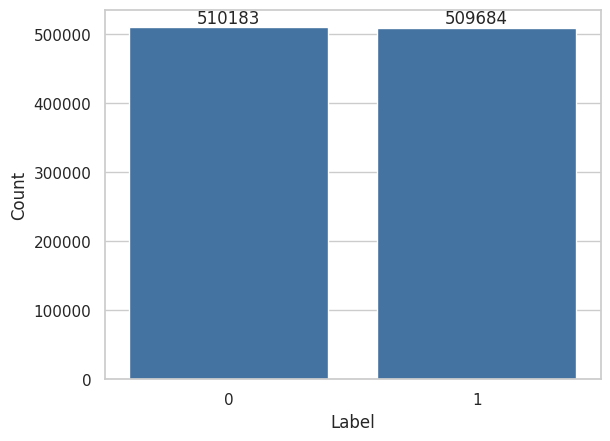

In [ ]:
sns.set_theme(style="whitegrid")

ax = sns.countplot(x='label', data=df, color='#3572B0')
ax.bar_label(ax.containers[0])
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
print("Value counts in label column:")
print(df['label'].value_counts())

plt.show()

Feature Engineering

In [ ]:
X = df.copy()
feature_groups = {}

# TIMESTAMP FEATURES
X['timestamp'] = pd.to_datetime(X['timestamp'], format='mixed', errors='coerce')
X['is_time_missing'] = X['timestamp'].isna().astype('int8')
X['hr']  = X['timestamp'].dt.hour.fillna(0).astype('int8')
X['dow'] = X['timestamp'].dt.dayofweek.fillna(0).astype('int8')
X['is_wknd?']  = (X['dow'].isin([4, 5])).astype('int8')
X['is_night?'] = ((X['hr'] < 6) | (X['hr'] >= 23)).astype('int8')
X = X.drop(columns=['timestamp'])

feature_groups['time'] = ['hr', 'dow', 'is_wknd?', 'is_night?']

# USERNAME FEATURES
X['username'] = X['username'].astype(str)

# PASSWORD FEATURES
X['p_len'] = pd.to_numeric(X['password_length'], errors='coerce').fillna(0).astype('int8')
X['p_comp'] = pd.to_numeric(X['password_complexity'], errors='coerce').fillna(0).astype('int8')

X['has_num'] = X['password'].astype(str).apply(lambda x: 1 if any(c.isdigit() for c in str(x)) else 0).astype('int8')
X['has_spec'] = X['password'].astype(str).apply(
    lambda x: 1 if any((not c.isalnum()) and (not c.isspace()) for c in x) else 0
).astype('int8')

X['p_score'] = ((X['p_comp'] * X['p_len']) / 10).astype('float32')

feature_groups['password'] = ['p_len', 'p_comp', 'has_num', 'has_spec', 'p_score']

# IAT FEATURES
X['mean_iat'] = pd.to_numeric(X['mean_iat'], errors='coerce').fillna(0).astype('float32')
X['std_iat'] = pd.to_numeric(X['std_iat'], errors='coerce').fillna(0).astype('float32')
X['iat_var'] = (X['std_iat'] / (X['mean_iat'].clip(lower=1))).astype('float32')

feature_groups['iat'] = ['mean_iat', 'std_iat', 'iat_var']


# LOGIN FEATURES
X['tries'] = pd.to_numeric(X['login_attempt'], errors='coerce').fillna(0).astype('int16')
X['fails'] = pd.to_numeric(X['fail_attempt'], errors='coerce').fillna(0).astype('int16')
X['fail_rate'] = pd.to_numeric(X['fail_ratio'], errors='coerce').fillna(0).astype('float32')

feature_groups['login'] = ['tries', 'fails', 'fail_rate']

X['target'] = X['label'].astype('int8')
print("Target distribution (0: Normal, 1: Attack):")
print(X['target'].value_counts())

Target distribution (0: Normal, 1: Attack):
target
0    510183
1    509684
Name: count, dtype: int64


Train\Test split

In [ ]:
bad_features = ['label', 'target', 'status']
X_final = X.drop(columns=bad_features, errors='ignore')
y_final = X['target']

# 70% for Training
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(
    gss1.split(X_final, y_final, groups=X_final['src_ip']))

X_train = X_final.iloc[train_idx].copy()
y_train = y_final.iloc[train_idx].copy()
X_temp = X_final.iloc[temp_idx].copy()
y_temp = y_final.iloc[temp_idx].copy()

# 30% (15% for Test)(15% for Validation)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(
    gss2.split(X_temp, y_temp, groups=X_temp['src_ip']))

X_val = X_temp.iloc[val_idx].copy()
y_val = y_temp.iloc[val_idx].copy()
X_test = X_temp.iloc[test_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

print(f"Train: {len(X_train)} ({len(X_train)/len(X_final)*100:.2f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X_final)*100:.2f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X_final)*100:.2f}%)")

print("\n" + "="*50 + "\n")

def print_distribution(y, name):
    dist = y.value_counts(normalize=True) * 100
    print(f"{name} distribution:")
    print(dist)
    print("-" * 40)

print_distribution(y_train, "Train")
print_distribution(y_val, "Validation")
print_distribution(y_test, "Test")

train_ips = set(X_train['src_ip'])
val_ips   = set(X_val['src_ip'])
test_ips  = set(X_test['src_ip'])

print(f"\nOverlap Train-Val: {len(train_ips & val_ips)}")
print(f"Overlap Train-Test: {len(train_ips & test_ips)}")
print(f"Overlap Val-Test: {len(val_ips & test_ips)}")

X_train = X_train.drop(columns=['src_ip'])
X_val   = X_val.drop(columns=['src_ip'])
X_test  = X_test.drop(columns=['src_ip'])

print("\n src_ip removed")

Train: 704222 (69.05%)
Validation: 173022 (16.97%)
Test: 142623 (13.98%)


Train distribution:
target
0    52.530026
1    47.469974
Name: proportion, dtype: float64
----------------------------------------
Validation distribution:
target
1    59.585486
0    40.414514
Name: proportion, dtype: float64
----------------------------------------
Test distribution:
target
1    50.688879
0    49.311121
Name: proportion, dtype: float64
----------------------------------------

Overlap Train-Val: 0
Overlap Train-Test: 0
Overlap Val-Test: 0

 src_ip removed


In [ ]:
u_map = X_train['username'].value_counts(normalize=True)
for ds in [X_train, X_val, X_test]:
    ds['u_freq'] = ds['username'].map(u_map).fillna(0).astype('float32')
feature_groups['user'] = ['u_freq']


loc_map = X_train['location'].value_counts(normalize=True)
for ds in [X_train, X_val, X_test]:
    ds['loc_freq'] = ds['location'].map(loc_map).fillna(0).astype('float32')

asn_map = X_train['asn'].value_counts(normalize=True)
for ds in [X_train, X_val, X_test]:
    ds['asn_freq'] = ds['asn'].map(asn_map).fillna(0).astype('float32')
feature_groups['network'] = ['asn_freq', 'loc_freq']

failure_threshold = X['fail_rate'].quantile(0.95)
fast_limit = X['mean_iat'].quantile(0.05)
reg_limit  = X['std_iat'].quantile(0.10)

for ds in [X_train, X_val, X_test]:
    ds['is_v_fast?'] = (ds['mean_iat'] < fast_limit).astype('int8')
    ds['is_v_reg?']  = (ds['std_iat'] < reg_limit).astype('int8')
    ds['fail_rate']  = pd.to_numeric(ds['fail_ratio'], errors='coerce').fillna(0).astype('float32')
    ds['is_failure?'] = (ds['fail_rate'] >= failure_threshold).astype('int8')

    ds['risk_score'] = (
        ds['is_failure?'] * 3 +
        ds['is_v_fast?'] * 2 +
        (ds['p_score'] < 3).astype(int) * 2 +
        ds['is_night?'] * 1 +
        ds['is_wknd?'] * 1
    ).astype('int8')

feature_groups['iat'] = ['is_v_fast?', 'is_v_reg?']
feature_groups['login'] = ['fail_rate', 'is_failure?']
feature_groups['risk'] = ['risk_score']

Select Feature + Target

In [ ]:
# PREPARE TRAINING FEATURES
training_features = [
    'hr', 'dow', 'is_wknd?', 'is_night?',
    'p_len', 'p_comp', 'has_num', 'has_spec', 'p_score',
    'u_freq', 'loc_freq', 'asn_freq',
    'mean_iat', 'std_iat', 'iat_var','is_v_fast?', 'is_v_reg?',
    'tries', 'fails', 'fail_rate', 'is_failure?'
]

X_train_final = X_train[training_features].copy()
X_val_final   = X_val[training_features].copy()
X_test_final  = X_test[training_features].copy()

y_train_final = y_train.copy()
y_val_final   = y_val.copy()
y_test_final  = y_test.copy()

print("Select Features:")
print(f"Total features: {len(training_features)}")
print(f"Groups: {list(feature_groups.keys())}")
print(f"Feature matrix: {X_final.shape}")
print(f"Target vector: {y_final.shape}")
print(f"Target distribution:\n{y_final.value_counts().sort_index()}")

Select Features:
Total features: 21
Groups: ['time', 'password', 'iat', 'login', 'user', 'network', 'risk']
Feature matrix: (1019867, 33)
Target vector: (1019867,)
Target distribution:
target
0    510183
1    509684
Name: count, dtype: int64


Scale Features

In [ ]:
X_train_num = X_train.select_dtypes(include=['number']).drop(columns=['src_ip'], errors='ignore')
X_val_num   = X_val.select_dtypes(include=['number']).drop(columns=['src_ip'], errors='ignore')
X_test_num  = X_test.select_dtypes(include=['number']).drop(columns=['src_ip'], errors='ignore')

scaler = StandardScaler()
cols = X_train_num.columns

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final), columns=training_features)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_final), columns=training_features)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_final), columns=training_features)

Reshape Data For RNN

In [ ]:
X_train_rnn = X_train_scaled.values.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_rnn = X_val_scaled.values.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_rnn = X_test_scaled.values.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"X_train_rnn shape: {X_train_rnn.shape}")
print(f"X_val_rnn shape: {X_val_rnn.shape}")
print(f"X_test_rnn shape: {X_test_rnn.shape}")

X_train_rnn shape: (704222, 21, 1)
X_val_rnn shape: (173022, 21, 1)
X_test_rnn shape: (142623, 21, 1)


Class Weight

In [ ]:
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
print(f"  Normal (0): {class_weight_dict[0]:.3f}")
print(f"  Attack (1): {class_weight_dict[1]:.3f}")

Class weights:
  Normal (0): 0.952
  Attack (1): 1.053


Build RNN Model

In [ ]:
def create_rnn_model_binary(input_shape):
    model = models.Sequential([

        # Input layer
        layers.Input(shape=input_shape),

        # Conv1D Block 1
        layers.Conv1D(128, kernel_size=3, activation='tanh'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Conv1D Block 2
        layers.Conv1D(64, kernel_size=3, activation='tanh'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Conv1D Block 3
        layers.Conv1D(32, kernel_size=3, activation='tanh'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Flatten the output before feeding to Dense layers
        layers.Flatten(),

        # Dense layers for classification
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Create model
rnn_model = create_rnn_model_binary((X_train_rnn.shape[1], 1))

In [ ]:
# Model summary
print("\n RNN Architecture:")
rnn_model.summary()

# Compile model
rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_rnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
callbacks = [early_stop, reduce_lr, checkpoint]


 RNN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 19, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        30,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,121 (254.38 KB)

 Trainable params: 64,673 (252.63 KB)

 Non-trainable params: 448 (1.75 KB)

Train RNN Model

In [ ]:
history = rnn_model.fit(
    X_train_rnn,
    y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7576 - loss: 0.4569
Epoch 1: val_accuracy improved from None to 0.81945, saving model to best_rnn_model.h5



Epoch 1: finished saving model to best_rnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 172s 118ms/step - accuracy: 0.7797 - loss: 0.4178 - val_accuracy: 0.8195 - val_loss: 0.3309 - learning_rate: 0.0010
Epoch 2/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7959 - loss: 0.3870
Epoch 2: val_accuracy improved from 0.81945 to 0.82325, saving model to best_rnn_model.h5



Epoch 2: finished saving model to best_rnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 203s 119ms/step - accuracy: 0.7975 - loss: 0.3837 - val_accuracy: 0.8232 - val_loss: 0.3325 - learning_rate: 0.0010
Epoch 3/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8004 - loss: 0.3774
Epoch 3: val_accuracy improved from 0.82325 to 0.82962, saving model to best_rnn_model.h5



Epoch 3: finished saving model to best_rnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 164s 119ms/step - accuracy: 0.8014 - loss: 0.3755 - val_accuracy: 0.8296 - val_loss: 0.3233 - learning_rate: 0.0010
Epoch 4/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8045 - loss: 0.3711
Epoch 4: val_accuracy improved from 0.82962 to 0.83278, saving model to best_rnn_model.h5



Epoch 4: finished saving model to best_rnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 164s 119ms/step - accuracy: 0.8049 - loss: 0.3698 - val_accuracy: 0.8328 - val_loss: 0.3220 - learning_rate: 0.0010
Epoch 5/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8064 - loss: 0.3674
Epoch 5: val_accuracy improved from 0.83278 to 0.83497, saving model to best_rnn_model.h5



Epoch 5: finished saving model to best_rnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 167s 121ms/step - accuracy: 0.8069 - loss: 0.3661 - val_accuracy: 0.8350 - val_loss: 0.3180 - learning_rate: 0.0010
Epoch 6/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8080 - loss: 0.3645
Epoch 6: val_accuracy improved from 0.83497 to 0.83803, saving model to best_rnn_model.h5



Epoch 6: finished saving model to best_rnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 164s 119ms/step - accuracy: 0.8083 - loss: 0.3636 - val_accuracy: 0.8380 - val_loss: 0.3269 - learning_rate: 0.0010
Epoch 7/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8088 - loss: 0.3627
Epoch 7: val_accuracy did not improve from 0.83803
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 164s 119ms/step - accuracy: 0.8091 - loss: 0.3618 - val_accuracy: 0.8371 - val_loss: 0.3283 - learning_rate: 0.0010
Epoch 8/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8094 - loss: 0.3610
Epoch 8: val_accuracy did not improve from 0.83803
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 168s 122ms/step - accuracy: 0.8100 - loss: 0.3603 - val_accuracy: 0.8379 - val_loss: 0.3241 - learning_rate: 0.0010
Epoch 9/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8113 - loss: 0.3600
Epoch 9: val_accuracy did not improve from 0.83803
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 163s 118ms/step - accuracy: 0.8113 - loss: 0.3594 - 


Epoch 11: finished saving model to best_rnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 163s 118ms/step - accuracy: 0.8139 - loss: 0.3551 - val_accuracy: 0.8397 - val_loss: 0.3424 - learning_rate: 5.0000e-04
Epoch 12/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8136 - loss: 0.3552
Epoch 12: val_accuracy did not improve from 0.83966
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 161s 117ms/step - accuracy: 0.8140 - loss: 0.3547 - val_accuracy: 0.8395 - val_loss: 0.3382 - learning_rate: 5.0000e-04
Epoch 13/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8140 - loss: 0.3548
Epoch 13: val_accuracy improved from 0.83966 to 0.84087, saving model to best_rnn_model.h5



Epoch 13: finished saving model to best_rnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 166s 120ms/step - accuracy: 0.8141 - loss: 0.3541 - val_accuracy: 0.8409 - val_loss: 0.3239 - learning_rate: 5.0000e-04
Epoch 14/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8150 - loss: 0.3536
Epoch 14: val_accuracy did not improve from 0.84087
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 200s 119ms/step - accuracy: 0.8149 - loss: 0.3535 - val_accuracy: 0.8405 - val_loss: 0.3223 - learning_rate: 5.0000e-04
Epoch 15/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8148 - loss: 0.3533
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 15: val_accuracy did not improve from 0.84087
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 167s 121ms/step - accuracy: 0.8149 - loss: 0.3531 - val_accuracy: 0.8386 - val_loss: 0.3293 - learning_rate: 5.0000e-04
Epoch 16/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8153 - loss: 0.3524
Epoch 16: val_accuracy did not improve


Epoch 18: finished saving model to best_rnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 163s 119ms/step - accuracy: 0.8164 - loss: 0.3509 - val_accuracy: 0.8417 - val_loss: 0.3327 - learning_rate: 2.5000e-04
Epoch 19/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8161 - loss: 0.3506
Epoch 19: val_accuracy did not improve from 0.84168
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 176s 128ms/step - accuracy: 0.8160 - loss: 0.3505 - val_accuracy: 0.8396 - val_loss: 0.3383 - learning_rate: 2.5000e-04
Epoch 20/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8166 - loss: 0.3506
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 20: val_accuracy did not improve from 0.84168
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 196s 124ms/step - accuracy: 0.8166 - loss: 0.3505 - val_accuracy: 0.8408 - val_loss: 0.3347 - learning_rate: 2.5000e-04
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 5.


Model Evaluation

In [ ]:
y_train_pred_probs = rnn_model.predict(X_train_scaled)
y_val_pred_probs   = rnn_model.predict(X_val_scaled)
y_test_pred_probs  = rnn_model.predict(X_test_scaled)

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_train_pred = (y_train_pred_probs > 0.5).astype(int)
y_val_pred   = (y_val_pred_probs > 0.5).astype(int)
y_test_pred  = (y_test_pred_probs > 0.5).astype(int)

# Accuracy scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("Accuracy Scores:")
print(f"  • Training: {train_acc:.4f}")
print(f"  • Test: {test_acc:.4f}")
print(f"  • Validation: {val_acc:.4f}")
print(f"  • F1-Score (Weighted): {test_f1:.4f}")

print("Unique in y_test:", np.unique(y_test))
print("Unique in y_test_pred:", np.unique(y_test_pred))


22007/22007 ━━━━━━━━━━━━━━━━━━━━ 87s 4ms/step
5407/5407 ━━━━━━━━━━━━━━━━━━━━ 33s 6ms/step
4457/4457 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step
Accuracy Scores:
  • Training: 0.8162
  • Test: 0.8081
  • Validation: 0.8350
  • F1-Score (Weighted): 0.8079
Unique in y_test: [0 1]
Unique in y_test_pred: [0 1]


Accuracy comparison bar chart

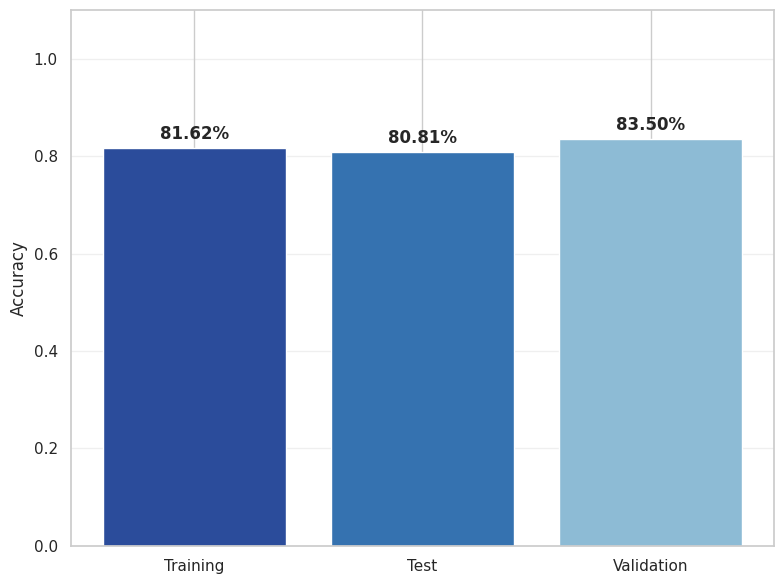

In [ ]:
plt.figure(figsize=(8, 6))
accuracies = [train_acc, test_acc, val_acc]
bars = plt.bar(['Training', 'Test', 'Validation'], accuracies,
               color=['#2B4C9B', '#3572B0', '#8DBBD5'])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Class Distribution Bar chart

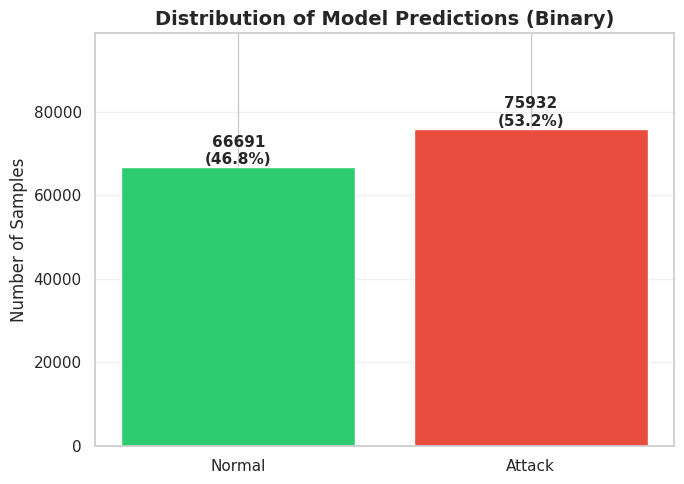

In [ ]:
plt.figure(figsize=(7, 5))
colors = ['#2ECC71', '#E74C3C']

class_names = ['Normal', 'Attack']

class_counts = pd.Series(y_test_pred.flatten()).value_counts().sort_index()
total = len(y_test_pred)

bars = plt.bar(class_names, [class_counts.get(i, 0) for i in range(2)], color=colors)

plt.ylim(0, class_counts.max() * 1.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribution of Model Predictions (Binary)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

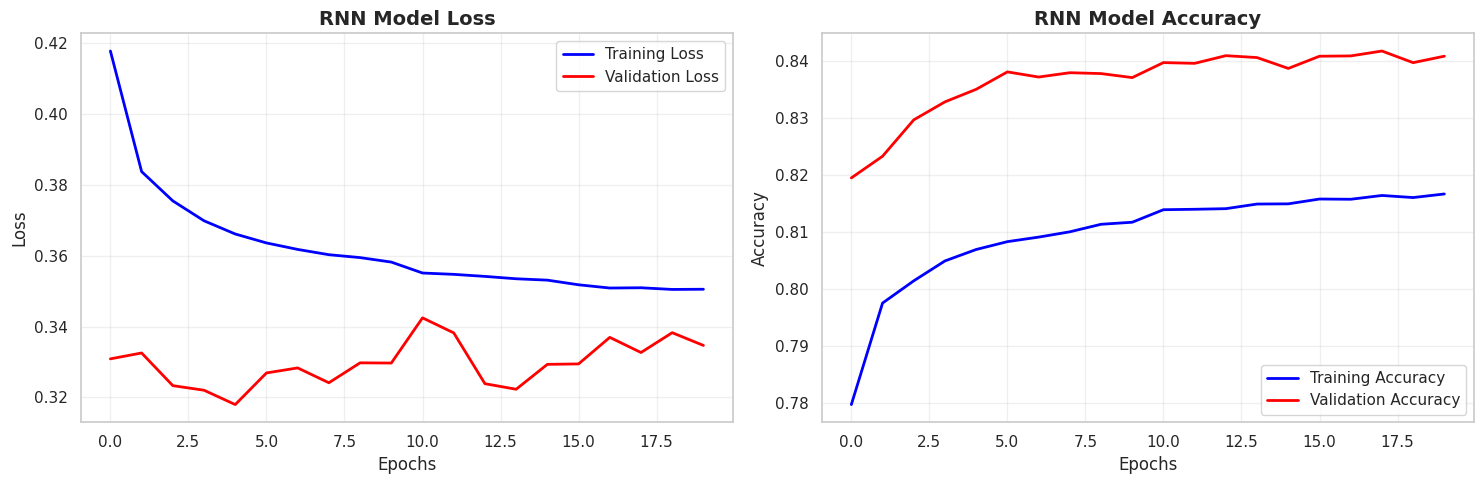

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[0].set_title('RNN Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
axes[1].set_title('RNN Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Mutual Information

Top 15 Mutual Information Scores:
                Feature  MI_Score
5              mean_iat  0.185515
23              iat_var  0.170511
6               std_iat  0.167232
4            fail_ratio  0.137313
26            fail_rate  0.133619
8   password_complexity  0.104856
25                fails  0.103102
18                p_len  0.102912
22              p_score  0.101952
19               p_comp  0.099726
3          fail_attempt  0.097545
7       password_length  0.096974
1                   iat  0.076517
2         login_attempt  0.052495
24                tries  0.050498


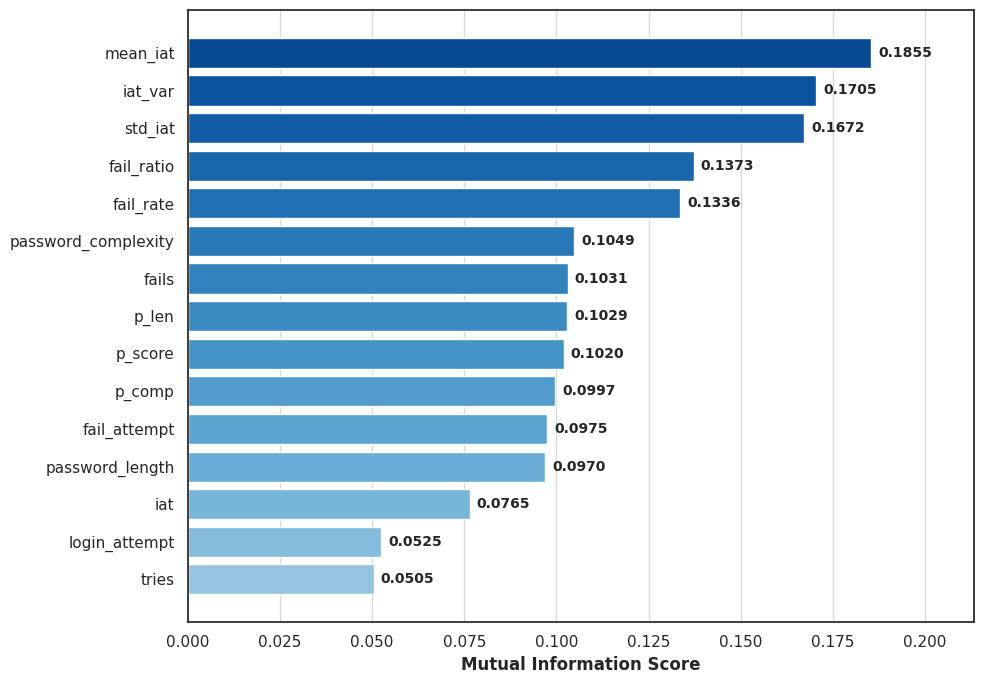

In [ ]:
feature_columns = X_final.select_dtypes(include=['number']).columns

X_train_df = pd.DataFrame(X_train, columns=feature_columns)

X_train_df = X_train_df.fillna(0)

sample_idx = np.random.choice(len(X_train_df), size=20000, replace=False)
X_sample = X_train_df.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)

mi_df = pd.DataFrame({
    'Feature': feature_columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print("Top 15 Mutual Information Scores:")
print(mi_df.head(15))

plt.figure(figsize=(10, 7))
top_15_mi = mi_df.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_15_mi)))

bars = plt.barh(range(len(top_15_mi)), top_15_mi['MI_Score'].values, color=colors[::-1])

plt.grid(visible=True, axis='x', color='black', linestyle='-', alpha=0.15)
plt.yticks(range(len(top_15_mi)), top_15_mi['Feature'].values)
plt.xlabel('Mutual Information Score', fontsize=12, fontweight='bold')

plt.gca().invert_yaxis()
plt.xlim(0, top_15_mi['MI_Score'].max() * 1.15)

for i, (bar, val) in enumerate(zip(bars, top_15_mi['MI_Score'].values)):
    plt.text(
        bar.get_width() + (top_15_mi['MI_Score'].max() * 0.01),
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Feature Importance

        Feature  MI_Score
11     asn_freq  0.266544
10     loc_freq  0.204353
12     mean_iat  0.174745
13      std_iat  0.164660
14      iat_var  0.158377
9        u_freq  0.152029
19    fail_rate  0.149548
5        p_comp  0.101632
8       p_score  0.099875
4         p_len  0.099824
18        fails  0.074708
20  is_failure?  0.055497
6       has_num  0.054110
17        tries  0.032957
3     is_night?  0.029877


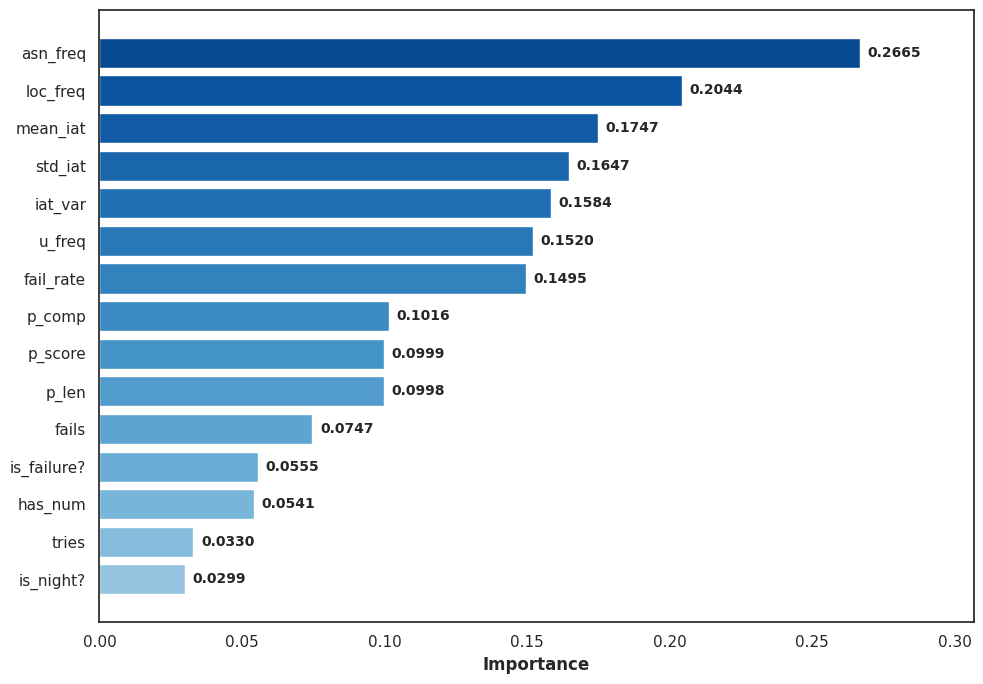

In [ ]:
mi_scores = mutual_info_classif(X_train_final, y_train, random_state=42)
feature_columns = X_train_final.columns

mi_df = pd.DataFrame({
    'Feature': feature_columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print(mi_df.head(15))

plt.figure(figsize=(10, 7))

top_15_mi = mi_df.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_15_mi)))

bars = plt.barh(range(len(top_15_mi)), top_15_mi['MI_Score'].values, color=colors[::-1])

plt.yticks(range(len(top_15_mi)), top_15_mi['Feature'].values)
plt.xlabel('Importance', fontsize=12, fontweight='bold')

plt.gca().invert_yaxis()

plt.xlim(0, top_15_mi['MI_Score'].max() * 1.15)

for i, (bar, val) in enumerate(zip(bars, top_15_mi['MI_Score'].values)):
    plt.text(bar.get_width() + (top_15_mi['MI_Score'].max() * 0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}',
             va='center',
             fontsize=10,
             fontweight='bold')

plt.tight_layout()
plt.show()

Correlation Matrix

In [ ]:
report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=['Normal', 'Attack'],
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report_dict).transpose()

for col in ['precision', 'recall', 'f1-score']:
    df_report[col] = df_report[col].apply(lambda x: f"{x*100:.2f}%")

display(df_report)

,precision,recall,f1-score,support
Normal,82.21%,77.96%,80.03%,70329.000000
Attack,79.58%,83.59%,81.54%,72294.000000
accuracy,80.81%,80.81%,80.81%,0.808109
macro avg,80.90%,80.77%,80.78%,142623.000000
weighted avg,80.88%,80.81%,80.79%,142623.000000


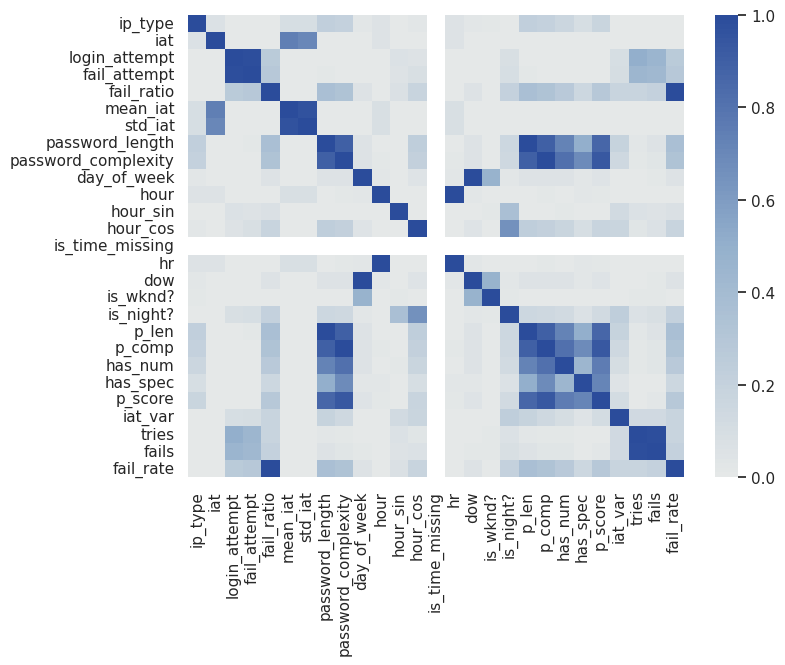

In [ ]:
plt.figure(figsize=(8,6))
colors = ["#E5E8E8", "#94B0CC", "#2B4C9B"]
n_bins = 100
sns.set_style("white")
cmap_name = "gray_to_blue"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
corr_matrix = X_final.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap=custom_cmap, annot=False, fmt=".2f", vmin=0, vmax=1)
plt.show()

Confusion Matrix

4457/4457 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step


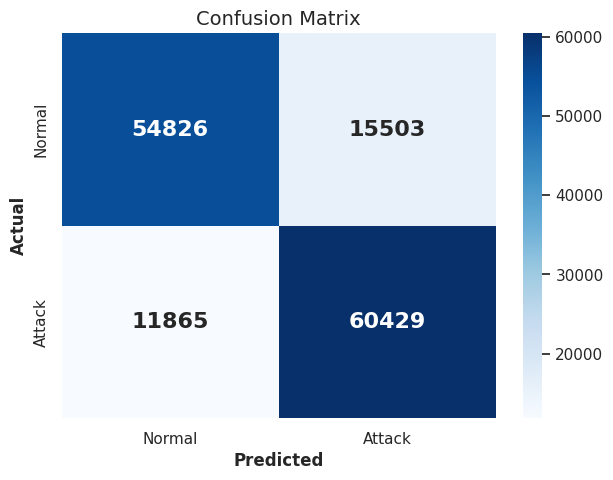

In [ ]:
class_names = ['Normal', 'Attack']

y_test_pred_probs = rnn_model.predict(X_test_scaled)
y_test_pred = (y_test_pred_probs > 0.5).astype(int) # Convert probabilities to binary predictions

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues",
            annot_kws={"size": 16, "weight": "bold"})

plt.xlabel("Predicted", fontsize=12, fontweight='bold')
plt.ylabel("Actual", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix", fontsize=14)
plt.show()

Classification report heatmap

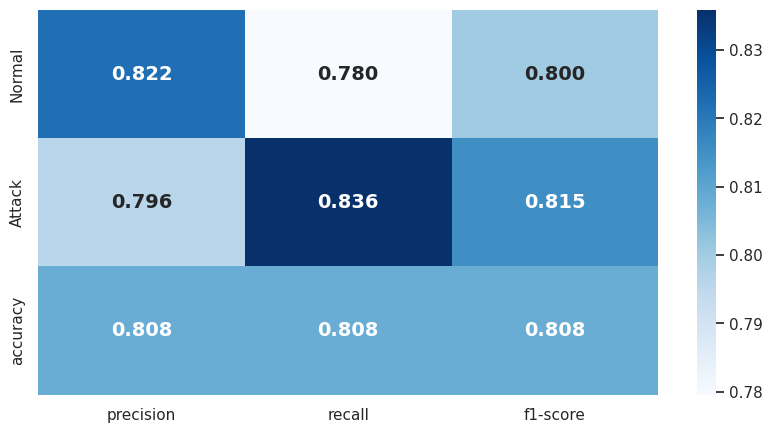

In [ ]:
report = classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=['Normal', 'Attack'],
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).iloc[:-1, :3].T

plt.figure(figsize=(10, 5))
sns.heatmap(report_df, annot=True, fmt=".3f",
            cmap="Blues", annot_kws={"size": 14, "weight": "bold"})
plt.show()

Operational Performance & Security Metrics

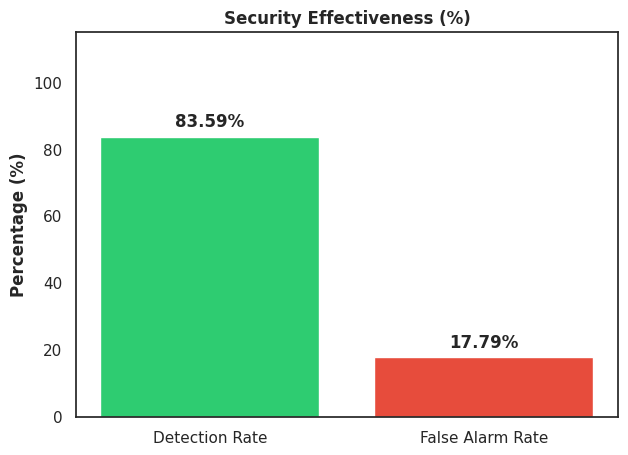

In [ ]:
attack_recall = report['Attack']['recall']
normal_precision = report['Normal']['precision']

detection_rate = attack_recall * 100
far_rate = (1 - normal_precision) * 100

fig, ax1 = plt.subplots(figsize=(7, 5))

metrics = ['Detection Rate', 'False Alarm Rate']
values = [detection_rate, far_rate]

ax1.bar(metrics, values, color=['#2ECC71', '#E74C3C'])

ax1.set_ylim(0, 115)
ax1.set_title('Security Effectiveness (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontweight='bold')

for i, v in enumerate(values):
    ax1.text(i, v + 3, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

SHAP Explanation

In [ ]:
background_for_explainer = X_train_rnn[:100]  # 100 samples for background
X_sample_for_explainer = X_test_rnn[:10]      # Use 10 samples for explanation consistency
X_sample_for_plot = X_test[:10]                # Use 10 samples for plotting consistency

In [ ]:
print("SHAP Explanation (DNN):")
explainer = shap.DeepExplainer(rnn_model, background_for_explainer.reshape(background_for_explainer.shape[0], background_for_explainer.shape[1], 1))
shap_values = explainer.shap_values(X_sample_for_explainer.reshape(X_sample_for_explainer.shape[0], X_sample_for_explainer.shape[1], 1))

if isinstance(shap_values, list):
    shap_values_reshaped = shap_values[0].squeeze()
else:
    shap_values_reshaped = shap_values.squeeze()
    print(f"SHAP values shape: {shap_values_reshaped.shape}")

SHAP Explanation (DNN):
SHAP values shape: (10, 21)



 Beeswarm Plot - Class 0 (Normal)


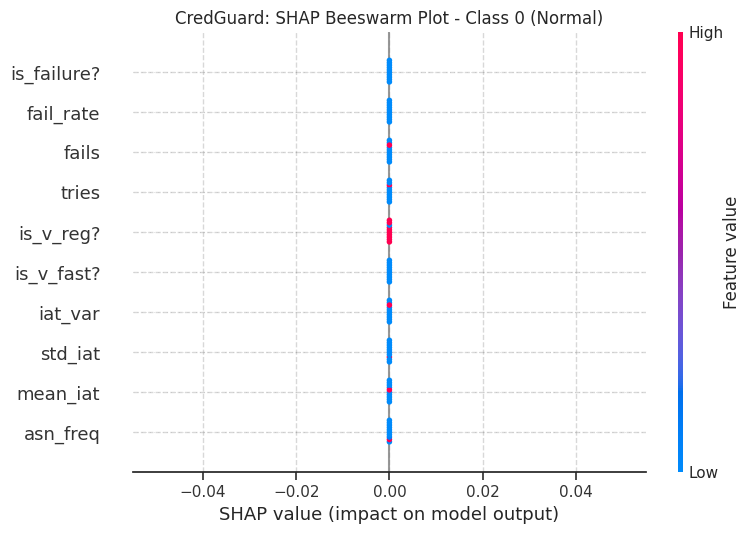


 Beeswarm Plot - Class 1 (Attack)


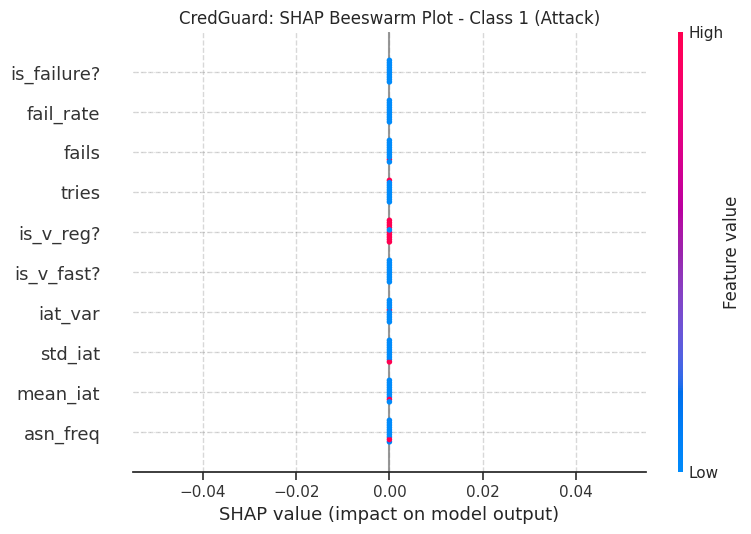

In [ ]:
# Beeswarm plots

shap_values_class_1 = shap_values_reshaped
shap_values_class_0 = -shap_values_reshaped

print("\n Beeswarm Plot - Class 0 (Normal)")
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class_0,
    X_test_scaled[:10], # Use 2D feature data for plotting
    feature_names=X_test_scaled.columns.tolist(),
    max_display=10,
    plot_type="dot",
    show=False
)
plt.title("CredGuard: SHAP Beeswarm Plot - Class 0 (Normal)")
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.tight_layout()
plt.show()


print("\n Beeswarm Plot - Class 1 (Attack)")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class_1,
    X_test_scaled[:10], # Use 2D feature data for plotting
    feature_names=X_test_scaled.columns.tolist(),
    max_display=10,
    plot_type="dot",
    show=False
)
plt.title("CredGuard: SHAP Beeswarm Plot - Class 1 (Attack)")
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.tight_layout()
plt.show()


Global Feature Importance


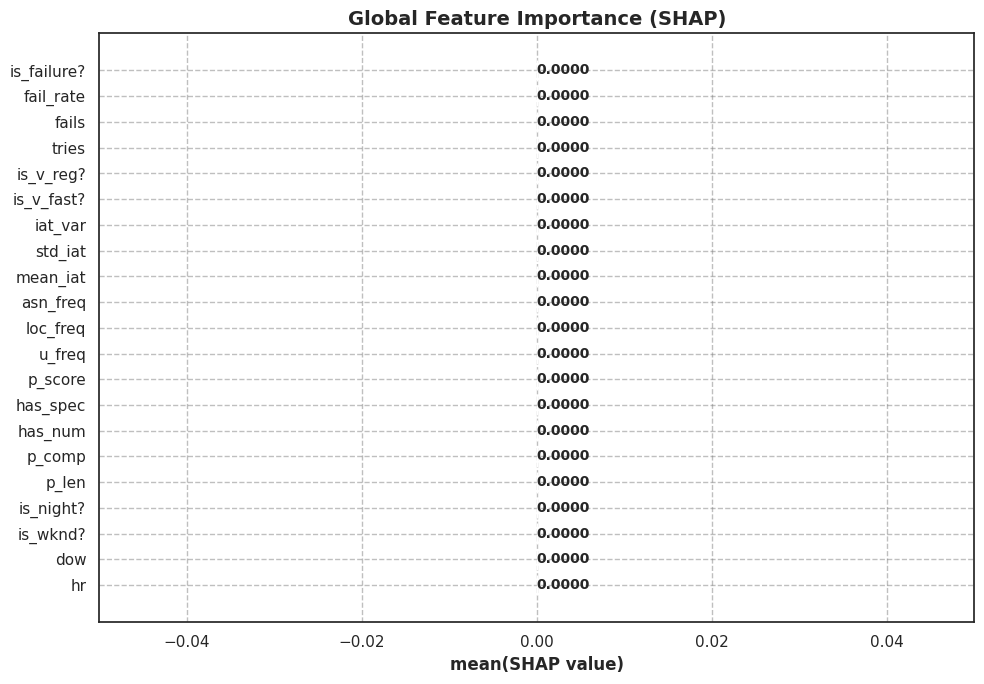

In [ ]:
# Global Feature Importance
print("\nGlobal Feature Importance")

if isinstance(shap_values, list):
    shap_array_for_global = np.stack([s.squeeze() for s in shap_values], axis=-1)
else:
    shap_array_for_global = shap_values.squeeze()

mean_abs_shap = np.mean(np.abs(shap_array_for_global), axis=0)
importance = mean_abs_shap

feature_names = np.array(training_features)
indices = np.argsort(importance)[::-1]
labels_for_plot = feature_names[indices].tolist()
importance_sorted = importance[indices]

plt.figure(figsize=(10, 7))

top_n = len(labels_for_plot)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))
bars = plt.barh(range(top_n), importance_sorted, color=colors[::-1])

plt.yticks(range(top_n), labels_for_plot)
plt.xlabel('mean(SHAP value)', fontsize=12, fontweight='bold')
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')

plt.gca().invert_yaxis()

plt.xlim(0, importance_sorted.max() * 1.15)

for i, (bar, val) in enumerate(zip(bars, importance_sorted)):
    plt.text(bar.get_width() + (importance_sorted.max() * 0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}',
             va='center',
             fontsize=10,
             fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

LIME Explanation

In [ ]:
normal_indices = y_test[y_test == 0].index[:3].tolist()  # 3 Normal samples
attack_indices = y_test[y_test == 1].index[:3].tolist()  # 3 Attack samples

# Combine all samples
samples_to_explain = normal_indices + attack_indices

LIME EXPLANATION (DNN):

Random sample selected: 110604
True label: Normal
Model predicted: Normal (confidence: 0.983)
LIME explaining class: Attack

Feature Contributions:
p_comp                              → +0.1520
p_len                               → +0.0932
has_num                             → +0.0743
p_score                             → +0.0729
fail_rate                           → +0.0635
u_freq                              → -0.0289
fails                               → +0.0181
is_night?                           → -0.0115
is_failure?                         → +0.0112
dow                                 → +0.0036


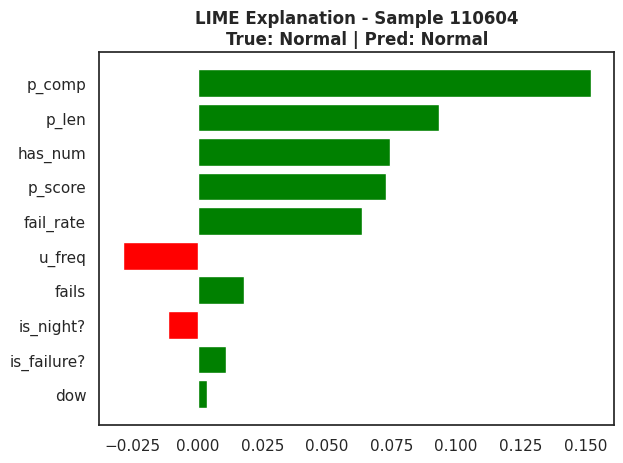

In [ ]:
print("LIME EXPLANATION (DNN):")
# Class names for binary
class_names = ['Normal', 'Attack']

def predict_proba_lime(X_unscaled):
    X_unscaled = np.array(X_unscaled)

    if X_unscaled.ndim == 1:
        X_unscaled = X_unscaled.reshape(1, -1)

    X_df = pd.DataFrame(X_unscaled, columns=training_features)

    X_scaled = scaler.transform(X_df)

    preds = rnn_model.predict(X_scaled, verbose=0)

    if preds.shape[1] == 1:
        preds = preds.flatten()
        return np.column_stack([1 - preds, preds])

    return preds

X_lime_background = X_train_final.values.astype(np.float64)
lime_feature_names = training_features

X_lime_background = X_train_final.values
lime_feature_names = training_features

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_lime_background,
    feature_names=lime_feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=False,
    random_state=42
)

sample_idx = random.randint(0, len(X_test_final) - 1)

sample_values = X_test_final.iloc[sample_idx].values

exp = explainer_lime.explain_instance(
    data_row=sample_values,
    predict_fn=predict_proba_lime,
    num_features=10
)

single_sample_df = pd.DataFrame(
    sample_values.reshape(1, -1),
    columns=training_features
)

single_sample_scaled = scaler.transform(single_sample_df)
pred_probs = rnn_model.predict(single_sample_scaled, verbose=0)

# Handle sigmoid output
if pred_probs.shape[1] == 1:
    pred_prob = pred_probs[0][0]
    pred_class_idx = 1 if pred_prob > 0.5 else 0
    confidence = pred_prob if pred_class_idx == 1 else 1 - pred_prob
else:
    pred_class_idx = np.argmax(pred_probs, axis=1)[0]
    confidence = pred_probs[0][pred_class_idx]

pred_class_name = class_names[pred_class_idx]

# Get true label
true_label = y_test_final.iloc[sample_idx]
true_label_name = class_names[true_label]

label_from_lime = exp.available_labels()[0]

print(f"\nRandom sample selected: {sample_idx}")
print(f"True label: {true_label_name}")
print(f"Model predicted: {pred_class_name} (confidence: {confidence:.3f})")
print(f"LIME explaining class: {class_names[label_from_lime]}")

if true_label != pred_class_idx:
    print(" MISCLASSIFICATION!")

print("\nFeature Contributions:")
for feature, weight in exp.as_list(label=label_from_lime):
   print(f"{feature:35} → {weight:+.4f}")

fig = exp.as_pyplot_figure(label=label_from_lime)

plt.title(
    f"LIME Explanation - Sample {sample_idx}\nTrue: {true_label_name} | Pred: {pred_class_name}",
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

SAVE MODEL

In [ ]:
rnn_model.save('rnn_ids_model.h5')

model_files = {

    'model': rnn_model,
    'scaler': scaler,
    'features': training_features
}

for name, obj in model_files.items():
    filename = f'rnn_ids_{name}.pkl'
    joblib.dump(obj, filename)
    print(f" Saved: {filename}")

 Saved: rnn_ids_model.pkl
 Saved: rnn_ids_scaler.pkl
 Saved: rnn_ids_features.pkl


In [ ]:
f1_scores_dict = {
    'Normal': report['Normal']['f1-score'],
    'Attack': report['Attack']['f1-score']
}
print(" FINAL SUMMARY - ALL METRICS")
top_features = mi_df.head(3)
print(f"""
╔══════════════════════════════════════════════════════════╗
║           RNN MODEL PERFORMANCE SUMMARY                  ║
╠══════════════════════════════════════════════════════════╣
║
║    ACCURACY:
║  • Training: {train_acc:.2%}
║  • Test: {test_acc:.2%}
║  • Validation: {val_acc:.2%}
║  • F1-Score (Weighted): {test_f1:.2%}
║
║    PER-CLASS F1-SCORES:
║  • Normal: {f1_scores_dict['Normal']:.2%}
║  • Attack: {f1_scores_dict['Attack']:.2%}
║
║    SECURITY METRICS:
║  • Detection Rate (Attack Recall): {detection_rate:.2f}%
║  • False Alarm Rate: {far_rate:.2f}%
║
║    TOP 5 FEATURES (Mutual Information):
║  • {mi_df.iloc[0]['Feature']}: {mi_df.iloc[0]['MI_Score']:.4f}
║  • {mi_df.iloc[1]['Feature']}: {mi_df.iloc[1]['MI_Score']:.4f}
║  • {mi_df.iloc[2]['Feature']}: {mi_df.iloc[2]['MI_Score']:.4f}
║  • {mi_df.iloc[3]['Feature']}: {mi_df.iloc[3]['MI_Score']:.4f}
║  • {mi_df.iloc[4]['Feature']}: {mi_df.iloc[4]['MI_Score']:.4f}
║
║    ARCHITECTURE:
║  • 3 Bidirectional LSTM layers (128 → 64 → 32)
║  • 2 Dense layers (64 → 32)
║  • BatchNormalization + Dropout for regularization
║  • Total parameters: ~{rnn_model.count_params():,}
║
╚══════════════════════════════════════════════════════════╝
""")

 FINAL SUMMARY - ALL METRICS

╔══════════════════════════════════════════════════════════╗
║           RNN MODEL PERFORMANCE SUMMARY                  ║
╠══════════════════════════════════════════════════════════╣
║
║    ACCURACY:
║  • Training: 81.62%
║  • Test: 80.81%
║  • Validation: 83.50%
║  • F1-Score (Weighted): 80.79%
║
║    PER-CLASS F1-SCORES:
║  • Normal: 80.03%
║  • Attack: 81.54%
║
║    SECURITY METRICS:
║  • Detection Rate (Attack Recall): 83.59%
║  • False Alarm Rate: 17.79%
║
║    TOP 5 FEATURES (Mutual Information):
║  • asn_freq: 0.2665
║  • loc_freq: 0.2044
║  • mean_iat: 0.1747
║  • std_iat: 0.1647
║  • iat_var: 0.1584
║
║    ARCHITECTURE:
║  • 3 Bidirectional LSTM layers (128 → 64 → 32)
║  • 2 Dense layers (64 → 32)
║  • BatchNormalization + Dropout for regularization
║  • Total parameters: ~65,121
║
╚══════════════════════════════════════════════════════════╝

